# Parsing

##### Autors: Josep de Cid & Gonzalo Recio

### Statement
- Expand the grammar of the example related to non-probabilistic chart parsers in order to subsume this new sentence.

- Perform the constituency parsing using a BottomUpChartParser, a BottomUpLeftCornerChartParser and a LeftCornerChartParser.

- For each one of them, provide the resulting tree, the number of edges and the list of explored edges.

In [1]:
import termtables as tt

from nltk import CFG
from nltk.parse.chart import BottomUpChartParser, BottomUpLeftCornerChartParser, LeftCornerChartParser

In [2]:
sentence = 'Lazy cats play with mice'
sentence = sentence.lower().split()

Expanding the grammar:

In [3]:
grammar = CFG.fromstring('''
S -> NP VP
NP -> NNS | JJ NNS | NP CC NP
VP -> VB NP | VB PP | VB
PP -> CC NP
NNS -> "cats" | "mice" | NNS CC NNS
VB  -> "play"
JJ  -> "lazy"
CC  -> "with"
''')

General parsing function for all the parsers:

In [4]:
def parse_sentence(G, method, text):
    parser = method(G)
    parse = list(parser.parse(text))
    edges = parser.chart_parse(text).edges()
    
    if len(parse) == 0:
        print('No result found')
    else:
        print(f'# Edges: {len(edges)}')
        for edge in edges:
            print(edge)
        return parse[0]

### Constituency Parsing 

#### BottomUpChartParser

# Edges: 52
[0:1] 'lazy'
[1:2] 'cats'
[2:3] 'play'
[3:4] 'with'
[4:5] 'mice'
[0:0] JJ -> * 'lazy'
[0:1] JJ -> 'lazy' *
[0:0] NP -> * JJ NNS
[0:1] NP -> JJ * NNS
[1:1] NNS -> * 'cats'
[1:2] NNS -> 'cats' *
[1:1] NP -> * NNS
[1:1] NNS -> * NNS CC NNS
[0:2] NP -> JJ NNS *
[1:2] NP -> NNS *
[1:2] NNS -> NNS * CC NNS
[1:1] S  -> * NP VP
[1:1] NP -> * NP CC NP
[1:2] S  -> NP * VP
[1:2] NP -> NP * CC NP
[0:0] S  -> * NP VP
[0:0] NP -> * NP CC NP
[0:2] S  -> NP * VP
[0:2] NP -> NP * CC NP
[2:2] VB -> * 'play'
[2:3] VB -> 'play' *
[2:2] VP -> * VB NP
[2:2] VP -> * VB PP
[2:2] VP -> * VB
[2:3] VP -> VB * NP
[2:3] VP -> VB * PP
[2:3] VP -> VB *
[1:3] S  -> NP VP *
[0:3] S  -> NP VP *
[3:3] CC -> * 'with'
[3:4] CC -> 'with' *
[3:3] PP -> * CC NP
[3:4] PP -> CC * NP
[4:4] NNS -> * 'mice'
[4:5] NNS -> 'mice' *
[4:4] NP -> * NNS
[4:4] NNS -> * NNS CC NNS
[4:5] NP -> NNS *
[4:5] NNS -> NNS * CC NNS
[4:4] S  -> * NP VP
[4:4] NP -> * NP CC NP
[3:5] PP -> CC NP *
[4:5] S  -> NP * VP
[4:5] NP -> NP * CC N

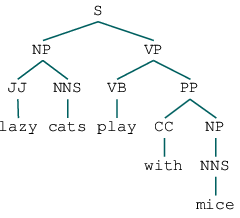

In [5]:
parse_sentence(grammar, BottomUpChartParser, sentence)

#### BottomUpLeftCornerChartParser

# Edges: 32
[0:1] 'lazy'
[1:2] 'cats'
[2:3] 'play'
[3:4] 'with'
[4:5] 'mice'
[0:1] JJ -> 'lazy' *
[0:1] NP -> JJ * NNS
[1:2] NNS -> 'cats' *
[1:2] NP -> NNS *
[1:2] NNS -> NNS * CC NNS
[0:2] NP -> JJ NNS *
[0:2] S  -> NP * VP
[0:2] NP -> NP * CC NP
[1:2] S  -> NP * VP
[1:2] NP -> NP * CC NP
[2:3] VB -> 'play' *
[2:3] VP -> VB * NP
[2:3] VP -> VB * PP
[2:3] VP -> VB *
[0:3] S  -> NP VP *
[1:3] S  -> NP VP *
[3:4] CC -> 'with' *
[3:4] PP -> CC * NP
[4:5] NNS -> 'mice' *
[4:5] NP -> NNS *
[4:5] NNS -> NNS * CC NNS
[4:5] S  -> NP * VP
[4:5] NP -> NP * CC NP
[3:5] PP -> CC NP *
[2:5] VP -> VB PP *
[0:5] S  -> NP VP *
[1:5] S  -> NP VP *


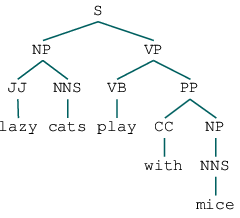

In [6]:
parse_sentence(grammar, BottomUpLeftCornerChartParser, sentence)

#### LeftCornerChartParser

# Edges: 25
[0:1] 'lazy'
[1:2] 'cats'
[2:3] 'play'
[3:4] 'with'
[4:5] 'mice'
[0:1] JJ -> 'lazy' *
[0:1] NP -> JJ * NNS
[1:2] NNS -> 'cats' *
[1:2] NP -> NNS *
[0:2] NP -> JJ NNS *
[0:2] S  -> NP * VP
[1:2] S  -> NP * VP
[2:3] VB -> 'play' *
[2:3] VP -> VB * PP
[2:3] VP -> VB *
[0:3] S  -> NP VP *
[1:3] S  -> NP VP *
[3:4] CC -> 'with' *
[3:4] PP -> CC * NP
[4:5] NNS -> 'mice' *
[4:5] NP -> NNS *
[3:5] PP -> CC NP *
[2:5] VP -> VB PP *
[0:5] S  -> NP VP *
[1:5] S  -> NP VP *


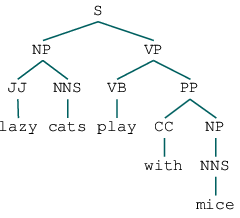

In [7]:
parse_sentence(grammar, LeftCornerChartParser, sentence)

# Conclusions (Mandatory)

### Which parser is the most efficient for parsing the sentence?
For parser we provided the resulting tree, the number of edges and the list of explored edges. We consider that the most efficient parser is the one that produces less edges and, hence the most efficient is the **LeftCornerChartParser** (with 25 generated edges for the given sentence). In constrast with the others it produces less than the half of the BottomUpChartParser (BottomUpChartParser: **52** edges vs. LeftCornerChartParser: **25** edges).

### Which edges are filtered out by each parser and why?
Each tried parser filtered more edges than the previous one, and that's what makes them different and more/less efficient. These are the filtered out edges for each one:
- BottomUpChartParser: generates all possible edges in a bottom-up strategy.
- BottomUpLeftCornerChartParser: filters out edges without any word subsumtion (for instance, \[1,1\] X --> Y).
- LeftCornerChartParser: filters out edges without any word subsumtion and edges that don't have new word subsumptions.


# Optional exercise

First we read the dataset into a list of pairs containing the sentences *\[(A1, B1), ..., (An, Bn)\]*

In [8]:
sentences = []

with open('trial/STS.input.txt', mode='r') as f:
    for idx, line in enumerate(f.readlines()):
        _, a, b = line.strip().split('\t')
        sentences.append([a, b])
        
        print(f'{idx + 1}a) {a}')
        print(f'{idx + 1}b) {b}\n')

1a) The bird is bathing in the sink.
1b) Birdie is washing itself in the water basin.

2a) In May 2010, the troops attempted to invade Kabul.
2b) The US army invaded Kabul on May 7th last year, 2010.

3a) John said he is considered a witness but not a suspect.
3b) "He is not a suspect anymore." John said.

4a) They flew out of the nest in groups.
4b) They flew into the nest together.

5a) The woman is playing the violin.
5b) The young lady enjoys listening to the guitar.

6a) John went horse back riding at dawn with a whole group of friends.
6b) Sunrise at dawn is a magnificent view to take in if you wake up early enough for it.



To run the following cells, you must download first the [Stanford Core NLP Server](https://stanfordnlp.github.io/CoreNLP/), and then run the server in a terminal with the following command:

```shell
java -mx4g -cp "*" edu.stanford.nlp.pipeline.StanfordCoreNLPServer -port 9000 -timeout 15000
```

In [9]:
from nltk import CoreNLPDependencyParser

parser = CoreNLPDependencyParser(url='http://localhost:9000')

In [10]:
parse = parser.raw_parse('Smith jumps over the lazy dog')
tree = next(parse)
for t in tree.triples():
    print(t)

(('jumps', 'VBZ'), 'nsubj', ('Smith', 'NNP'))
(('jumps', 'VBZ'), 'nmod', ('dog', 'NN'))
(('dog', 'NN'), 'case', ('over', 'IN'))
(('dog', 'NN'), 'det', ('the', 'DT'))
(('dog', 'NN'), 'amod', ('lazy', 'JJ'))


In [11]:
from nltk.metrics import jaccard_distance
import numpy as np

In [12]:
similarities = []

for sentence_a, sentence_b in sentences:
    parse_a = parser.raw_parse(sentence_a)
    parse_b = parser.raw_parse(sentence_b)
    
    t_a = list(next(parse_a).triples())
    t_b = list(next(parse_b).triples())
    
    sim = 1 - jaccard_distance(set(t_a), set(t_b))
    similarities.append(sim)
    
    print(t_a)
    print(t_b)
    print(f'\nJaccard Similarity = {sim}\n{"-"*50}\n')

[(('bathing', 'NN'), 'nsubj', ('bird', 'NN')), (('bird', 'NN'), 'det', ('The', 'DT')), (('bathing', 'NN'), 'cop', ('is', 'VBZ')), (('bathing', 'NN'), 'nmod', ('sink', 'NN')), (('sink', 'NN'), 'case', ('in', 'IN')), (('sink', 'NN'), 'det', ('the', 'DT')), (('bathing', 'NN'), 'punct', ('.', '.'))]
[(('washing', 'VBG'), 'nsubj', ('Birdie', 'NNP')), (('washing', 'VBG'), 'aux', ('is', 'VBZ')), (('washing', 'VBG'), 'dobj', ('itself', 'PRP')), (('washing', 'VBG'), 'nmod', ('basin', 'NN')), (('basin', 'NN'), 'case', ('in', 'IN')), (('basin', 'NN'), 'det', ('the', 'DT')), (('basin', 'NN'), 'compound', ('water', 'NN')), (('washing', 'VBG'), 'punct', ('.', '.'))]

Jaccard Similarity = 0.0
--------------------------------------------------

[(('attempted', 'VBN'), 'nmod', ('May', 'NNP')), (('May', 'NNP'), 'case', ('In', 'IN')), (('May', 'NNP'), 'nummod', ('2010', 'CD')), (('attempted', 'VBN'), 'punct', (',', ',')), (('attempted', 'VBN'), 'nsubj', ('troops', 'NNS')), (('troops', 'NNS'), 'det', ('th

In [13]:
print(tt.to_string(
        data=[[f'Pair {idx}', sim] for idx, sim in enumerate(similarities)],
        header=['Pair ', 'Jaccard Similiraty']
            
))

┌────────┬──────────────────────┐
│ Pair   │ Jaccard Similiraty   │
╞════════╪══════════════════════╡
│ Pair 0 │ 0.0                  │
├────────┼──────────────────────┤
│ Pair 1 │ 0.0                  │
├────────┼──────────────────────┤
│ Pair 2 │ 0.10526315789473684  │
├────────┼──────────────────────┤
│ Pair 3 │ 0.4                  │
├────────┼──────────────────────┤
│ Pair 4 │ 0.0                  │
├────────┼──────────────────────┤
│ Pair 5 │ 0.033333333333333326 │
└────────┴──────────────────────┘


# Conclusions (Optional)

### Could it be relevant to use NEs to compute the similarity between two sentences?
Using Named Entity Recognition, we could detect entities as a one and in some cases could help if they refere to the same entity, but if not, we would be worsening the results (coreference resolution problem (NECR)). For this case, if the reference is the same in both sentences, then NE would appear alltogether inside the triple instead of being divived into different triples and, hence, improve the similarity detection.